Data analysis code for Halsted et al. (202X), "Global analysis of in situ cosmogenic 26Al/10Be ratios in fluvial sediments indicates widespread sediment storage and burial during transport". 

To re-run these analyses you will first have to download Table S1, an Excel file. Then, copy the local file path to Table S1 and paste the file path in between the quotation marks in the first code block below.  

In [9]:
data_file_path = "/Users/ch22/Library/CloudStorage/GoogleDrive-ch22@williams.edu/My Drive/1. Projects - Work/Manuscript - Fluvial Ratios/Paper components/GeoChron Manuscript/Supplement/TS1_Published_Al_Be_Measurements_20Dec2024.xlsx"

The following python packages are used in this notebook. Use your preferred installation method and environment to make sure all packages are installed prior to running the rest of the notebook. I provide an example using pip in the next cell.

pandas, IPython, numpy, matplotlib, seaborn, scipy, statsmodels, scikit_posthocs, openpyxl, geopandas

In [10]:
#If needed, install the necessary packages, ensuring they can be used in the current notebook
#!pip3 install --upgrade cartopy

You have to run the following two blocks to run the rest of the blocks. These blocks load in the excel file, log-transform basin areas and apparent erosion rates, and rename the variables so that the remaining code is more easily understood. After running these two blocks, you can skip ahead to any other block if you'd like. All necessary packages for each block are imported separately, it is not assumed that you will have proceeded linearly through the preceeding blocks. 

In [11]:
import pandas as pd
from IPython.display import Markdown, display

df = pd.read_excel(data_file_path, sheet_name='Basin and Sample Data')
column_names = df.columns.tolist()
display(Markdown('\n'.join(f'- {col}' for col in column_names)))

- Unique ID
- OCTOPUS_ID
- Source ID
- AUTHOR
- PUBYEAR
- DOI
- Be-10 Concentration (atoms/g)
- Be-10 Conc Uncertainty (atoms/g)
- Al-26 Concentration (atoms/g)
- Al-26 Conc Uncertainty (atoms/g)
- Al-26/Be-10 Concentration Ratio
- Al-26/Be-10 Conc Ratio Uncertainty
- Be Erosion Rate (m/myr)
- Be Erosion Internal Uncertainty (m/myr)
- Be Erosion External Uncertainty (m/myr)
- Al Erosion Rate (m/myr)
- Al Erosion Internal Uncertainty (m/myr)
- Al Erosion External Uncertainty (m/myr)
- Be/Al Erosion Rate Ratio
- Be/Al Erosion Ratio Unc (int)
- Be/Al Erosion Ratio Unc (ext)
- Distinguishable from 1 (1-sigma) (1 = lower, 2 = higher)
- Distinguishable from 1 (2-sigma) (1 = lower, 2 = higher)
- Basin Central Latitude (°N)
- Basin Central Longitude (°E)
- Sampling Latitude (°N)
- Sampling Longitude (°E)
- Effective Atm. Pressure
- Basin Area (km2)
- Mean Basin Elevation - 90m raster (m a.s.l.)
- Mean Basin Elevation - 500m raster (m a.s.l.)
- Mean Basin Elevation - 1000m raster (m a.s.l.)
- Multi-Resolution Mean Basin Elevation (m a.s.l.)
- Mean Basin Slope - 90m raster (degrees)
- Mean Basin Slope - 500m raster (degrees)
- Mean Basin Slope - 1000m raster (degrees)
- Multi-Resolution Mean Basin Slope (degrees)
- Mean Local Relief (m/ 2km)
- Mean Local Relief Standard Deviation (m/ 2km)
- Basin Mean Annual Precipitation (mm)
- Basin Mean Aridity Index (AI Units)
- Intermittent Flow Probability
- Mean Strain Rate (mm/yr)
- Tectonics Classification
- Dominant Basin Lithology
- Number of lithologies in basin
- LGM Ice Cover (km2)
- LGM Ice Cover (%)
- Present Ice Cover  (km2)
- Present Ice Cover (%)
- Unnamed: 50
- Hypsometric Integral
- Sampled Material
- Size Min (micron)
- Size Max (micron)

In [12]:
import numpy as np

# Rename the key columns to make them easier to work with
df.rename(columns={
    'Be/Al Erosion Rate Ratio': 'Erosion_Rate_Ratio',
    'Be/Al Erosion Ratio Unc (int)':'E_Ratio_Unc',
    'Basin Central Latitude (°N)': 'Basin_Central_Latitude',
    'Basin Central Longitude (°E)': 'Basin_Central_Longitude',
    'Be Erosion Rate (m/myr)': 'Erosion_Rate',
    'Distinguishable from 1 (2-sigma) (1 = lower, 2 = higher)':'Ratio_Cat',
    'Basin Area (km2)': 'Basin_Area',
    'Multi-Resolution Mean Basin Elevation (m a.s.l.)': 'Mean_Elevation',
    'Multi-Resolution Mean Basin Slope (degrees)': 'Mean_Slope',
    'Mean Local Relief (m/ 2km)': 'Mean_Local_Relief',
    'Basin Mean Annual Precipitation (mm)': 'Annual_Precipitation',
    'Basin Mean Aridity Index (AI Units)': 'Aridity_Index',
    'Intermittent Flow Probability': 'Intermittent_Flow_Probability',
    'Tectonics Classification': 'STR_Class',
    'Dominant Basin Lithology': 'Lithology',
    'LGM Ice Cover (%)':'LGM_ice',
    'Present Ice Cover (%)':'Present_ice',
    'Hypsometric Integral':'Hypso_Int',
}, inplace=True)

#Log-transform erosion rates and basin areas and add the log values in as new variables
df['Log_Erosion'] = np.log(df['Erosion_Rate'])
df['Log_Area'] = np.log(df['Basin_Area'])

Visualizing and exploring the erosion rate ratio data. Histogram, normality checks, and statistics

Text(0, 0.5, 'Frequency')

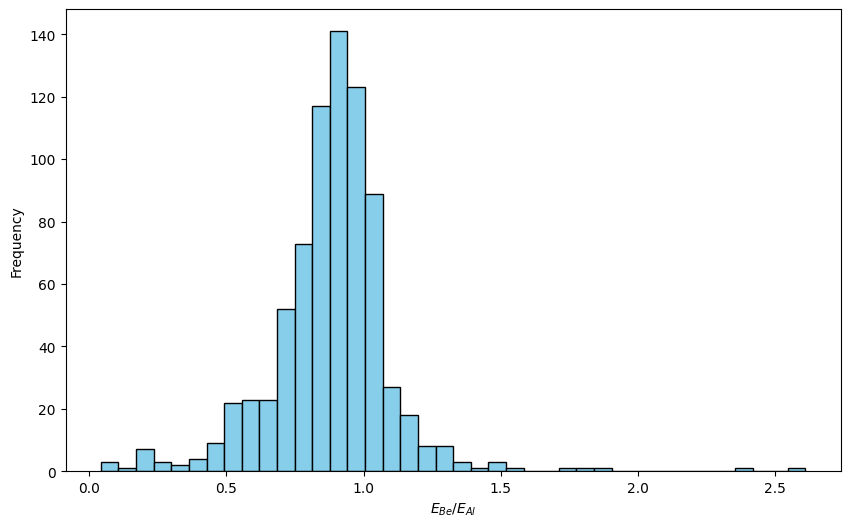

In [13]:
import matplotlib.pyplot as plt

# Specify the column for the histogram
selected_column = "Erosion_Rate_Ratio"

# Plot a histogram
plt.figure(figsize=(10, 6))
plt.hist(df[selected_column], bins=40, color='skyblue', edgecolor='black')
plt.xlabel(r'$E_{Be}/E_{Al}$')
plt.ylabel('Frequency')

Normality tests: first, Shapiro-Wilk test (if p-value is less than 0.05, the data is not normally distributed):

In [14]:
from scipy.stats import shapiro

# Shapiro-Wilk test for normality
stat, p_value = shapiro(df['Erosion_Rate_Ratio'])

# Display the results
print(f"Shapiro-Wilk Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The data is not normally distributed.")
else:
    print("The data appears to be normally distributed.")

Shapiro-Wilk Test Statistic: 0.88897414796679
P-value: 5.005594177469654e-23
The data is not normally distributed.


The histogram above suggests that the non-normality may be due to long tails, rather than the mostly normal-looking bulk of the data. Check this with a Q-Q plot for visual inspection:

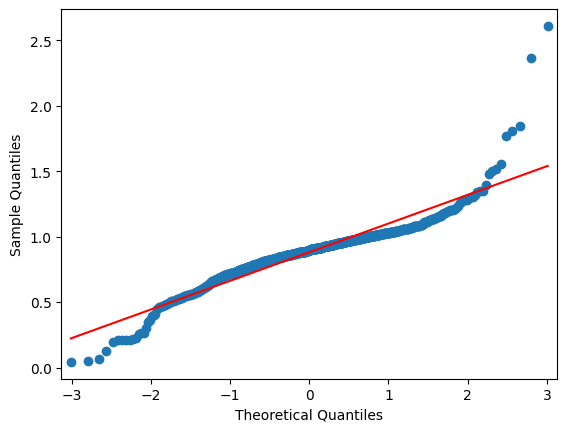

In [18]:
import statsmodels.api as sm

sm.qqplot(df['Erosion_Rate_Ratio'], line='s')
plt.show()

As expected, most values fall along the normality line, with only the extreme values displaying non-normality. We will proceed with calculating the population statistics treating this distribution as approximately normal.

In [19]:
#Display erosion rate ratio statistics
ERR_mean = df['Erosion_Rate_Ratio'].mean()
ERR_std = df['Erosion_Rate_Ratio'].std()
ERR_md = df['Erosion_Rate_Ratio'].median()

print(f'Erosion Rate Ratio Mean: {(ERR_mean):.3g}')
print(f'Erosion Rate Ratio Standard Deviation: {(ERR_std):.3g}')
print(f'Erosion Rate Ratio Median: {(ERR_md):.3g}')

Erosion Rate Ratio Mean: 0.881
Erosion Rate Ratio Standard Deviation: 0.219
Erosion Rate Ratio Median: 0.898


Simple hypothesis test to see if the number of samples with DRR values less than 1 exceeds expectations

In [20]:
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest

# Define the mean and standard deviation of the normal distribution
mean = 1
std_dev = df['Erosion_Rate_Ratio'].std()

# Calculate the expected proportion of values below 1
expected_proportion = norm.cdf(1, loc=mean, scale=std_dev)

# Count the actual proportion of values below 1 in the dataset
actual_count = (df['Erosion_Rate_Ratio'] < 1).sum()
total_count = df['Erosion_Rate_Ratio'].notna().sum()
actual_proportion = actual_count / total_count

# Perform a one-sample proportion test
stat, p_value = proportions_ztest(count=actual_count, nobs=total_count, value=expected_proportion, alternative='larger')

# Display the results
print(f"Expected Proportion Below 1: {expected_proportion:.4f}")
print(f"Actual Proportion Below 1: {actual_proportion:.4f}")
print(f"Z-Statistic: {stat:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Reject the null hypothesis: There are more values below 1 than expected.")
else:
    print("Fail to reject the null hypothesis: The proportion below 1 matches the expected.")


Expected Proportion Below 1: 0.5000
Actual Proportion Below 1: 0.7663
Z-Statistic: 17.4180
P-Value: 3.0108e-68
Reject the null hypothesis: There are more values below 1 than expected.


In [22]:
from scipy.stats import norm
from statsmodels.stats.proportion import proportions_ztest

# Define the mean and standard deviation of the normal distribution
mean = 1
std_dev = df['Erosion_Rate_Ratio'].std()

# Calculate the expected proportion of values above 1
expected_proportion = norm.cdf(1, loc=mean, scale=std_dev)

# Count the actual proportion of values below 1 in the dataset
actual_count = (df['Erosion_Rate_Ratio'] > 1).sum()
total_count = df['Erosion_Rate_Ratio'].notna().sum()
actual_proportion = actual_count / total_count

# Perform a one-sample proportion test
stat, p_value = proportions_ztest(count=actual_count, nobs=total_count, value=expected_proportion, alternative='larger')

# Display the results
print(f"Expected Proportion Above 1: {expected_proportion:.4f}")
print(f"Actual Proportion Above 1: {actual_proportion:.4f}")
print(f"Z-Statistic: {stat:.4f}")
print(f"P-Value: {p_value:.4e}")

if p_value < 0.05:
    print("Reject the null hypothesis: There are more values above 1 than expected.")
else:
    print("Fail to reject the null hypothesis: The proportion above 1 matches the expected.")


Expected Proportion Above 1: 0.5000
Actual Proportion Above 1: 0.2232
Z-Statistic: -18.3947
P-Value: 1.0000e+00
Fail to reject the null hypothesis: The proportion above 1 matches the expected.


Calculating the number of samples that are indistinguishable from 1, distinguishably higher than 1, and distinguishably lower than one using propagated analytical uncertainties (1-sigma):

In [23]:
import pandas as pd
import numpy as np

# Define a function to categorize each sample based on the individual error
def categorize_based_on_uncertainty(row):
    erosion_rate = row['Erosion_Rate_Ratio']
    unc = row['E_Ratio_Unc']
    
    # Define the thresholds based on the error (uncertainty)
    lower_threshold = erosion_rate - unc
    upper_threshold = erosion_rate + unc
    
    # Categorize the sample
    if lower_threshold <= 1 <= upper_threshold:
        return 'Indistinguishable from 1'
    elif erosion_rate < 1 - unc:
        return 'Distinguishably Lower than 1'
    elif erosion_rate > 1 + unc:
        return 'Distinguishably Higher than 1'
    else:
        return 'Indistinguishable from 1'

# Apply the categorization function to each row and create a new 'Category' column
df['Category 1S'] = df.apply(categorize_based_on_uncertainty, axis=1)

# Show the number of samples in each category
category_counts = df['Category 1S'].value_counts()

# Print the result
print(category_counts)


Category 1S
Distinguishably Lower than 1     408
Indistinguishable from 1         297
Distinguishably Higher than 1     61
Name: count, dtype: int64


And the same but with 2-sigma uncertainty:

In [24]:
import pandas as pd
import numpy as np

# Define a function to categorize each sample based on the individual error
def categorize_based_on_uncertainty(row):
    erosion_rate = row['Erosion_Rate_Ratio']
    unc = 2*row['E_Ratio_Unc']
    
    # Define the thresholds based on the error (uncertainty)
    lower_threshold = erosion_rate - unc
    upper_threshold = erosion_rate + unc
    
    # Categorize the sample
    if lower_threshold <= 1 <= upper_threshold:
        return 'Indistinguishable from 1'
    elif erosion_rate < 1 - unc:
        return 'Distinguishably Lower than 1'
    elif erosion_rate > 1 + unc:
        return 'Distinguishably Higher than 1'
    else:
        return 'Indistinguishable from 1'

# Apply the categorization function to each row and create a new 'Category' column
df['Category 2S'] = df.apply(categorize_based_on_uncertainty, axis=1)

# Show the number of samples in each category
category_counts = df['Category 2S'].value_counts()

# Print the result
print(category_counts)

Category 2S
Indistinguishable from 1         501
Distinguishably Lower than 1     238
Distinguishably Higher than 1     27
Name: count, dtype: int64


Code to make kernel density plots in figure 4. We used the 'pairplot' function in the seaborn package to create the kernel density plots color-coded by erosion rate ratio categories. We then exported the figure as an SVG file, removed the scatterplots, re-arranged the kernel density plots to be in a grid, and re-colored the kernel density plots to match the color scheme of other figures.

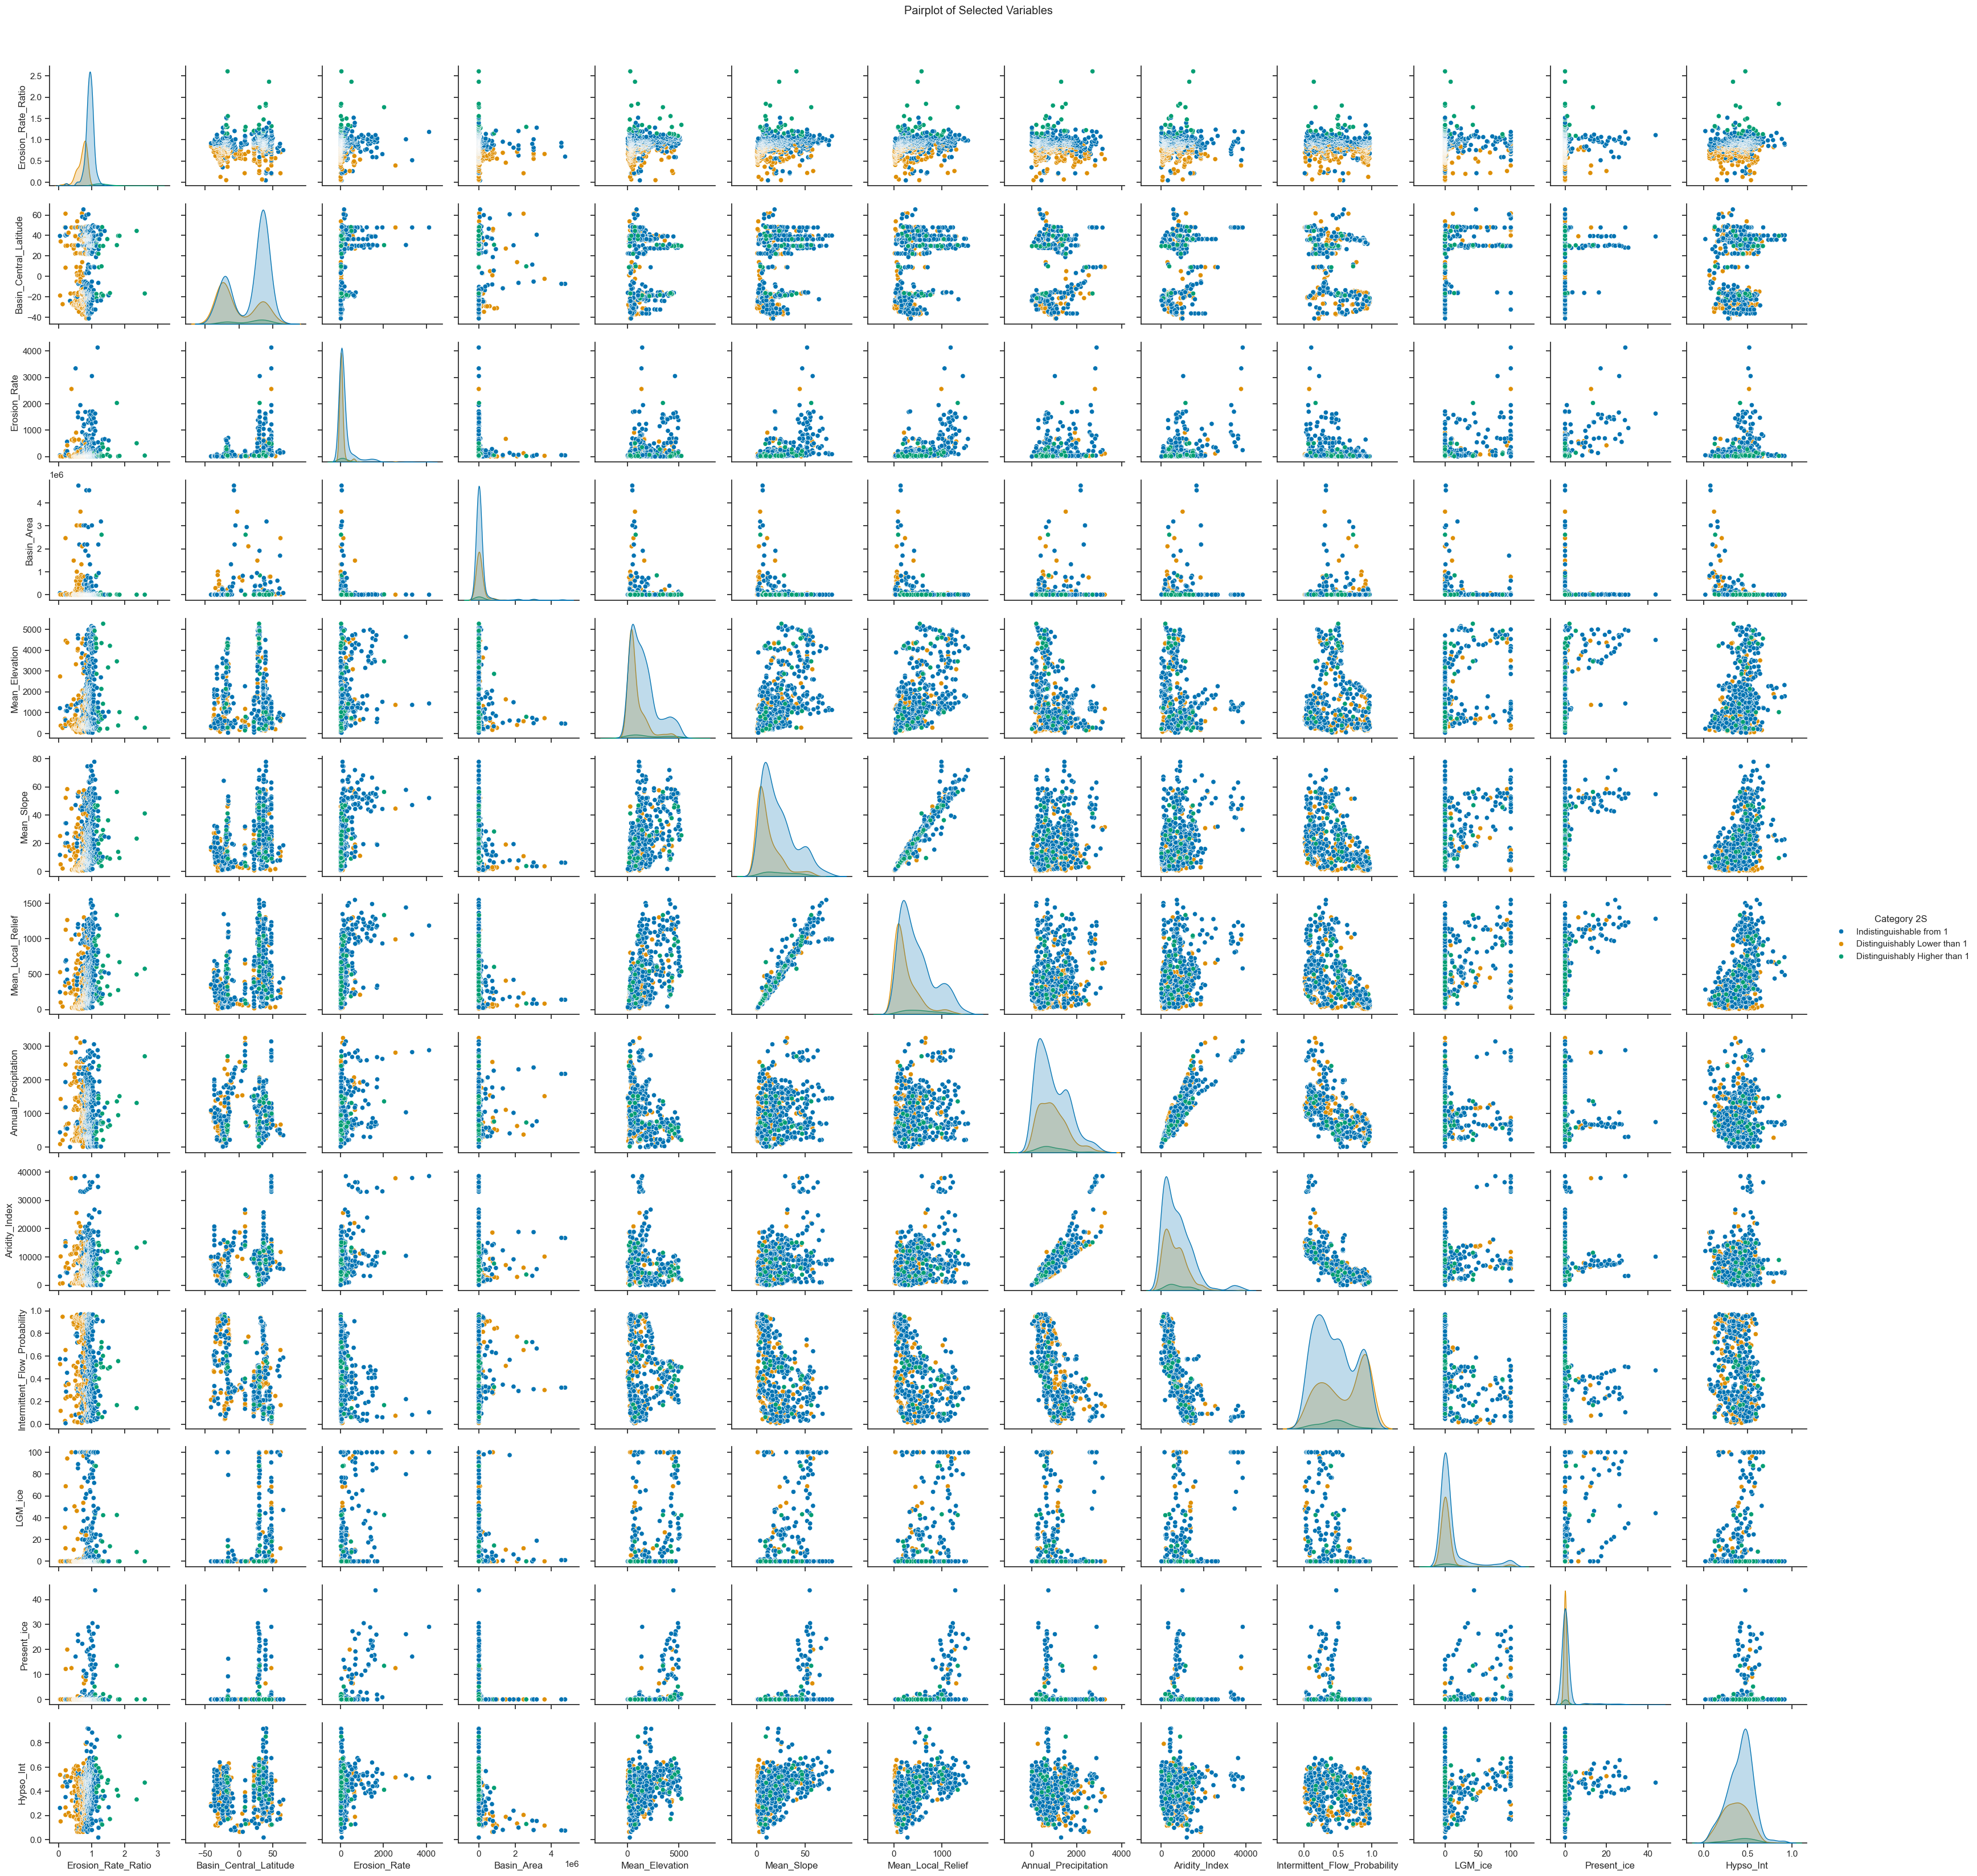

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the specified variables for correlation calculation
selected_variables = ['Erosion_Rate_Ratio', 'Basin_Central_Latitude', 'Erosion_Rate', 'Basin_Area', 
                      'Mean_Elevation', 'Mean_Slope', 'Mean_Local_Relief', 
                      'Annual_Precipitation', 'Aridity_Index', 'Intermittent_Flow_Probability',
                     'LGM_ice','Present_ice','Hypso_Int']
%matplotlib inline

# Plot scatterplots for each pair of variables with color-coded 'Ratio' values
sns.set(style="ticks")
g = sns.pairplot(df, hue='Category 2S', palette='colorblind', vars=selected_variables)

# Set title for the plot (optional)
g.fig.suptitle('Pairplot of Selected Variables', y=1.02)

# Save the figure as an SVG file
g.fig.savefig('pairplot_example.svg', format='svg')

# Show the plot
plt.show()

Code for Figure 5: Cross correlation heatmap and correlation p-values. The first block of code calculates Spearman's rank correlations between variables and plots the relationships in a heatmap. The second block calculates the p-values for correlations. To construct figure 5 we exported the correlation heatmap as an SVG file and modified the font styling of the correlation values to indicate p-values according to the key in figure 5.

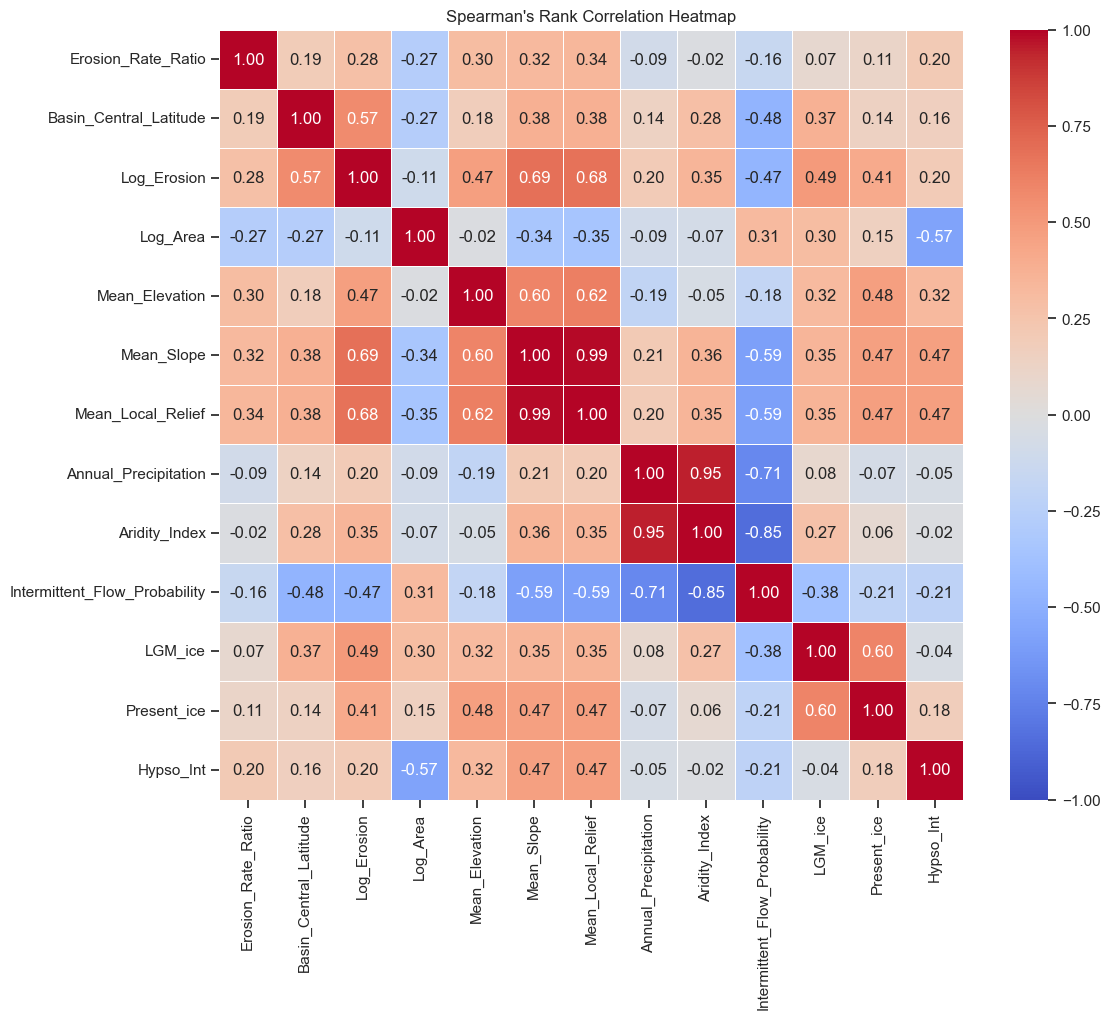

In [31]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the specified variables for correlation calculation
selected_variables = ['Erosion_Rate_Ratio', 'Basin_Central_Latitude', 'Log_Erosion', 'Log_Area', 
                      'Mean_Elevation', 'Mean_Slope', 'Mean_Local_Relief', 
                      'Annual_Precipitation', 'Aridity_Index', 'Intermittent_Flow_Probability',
                     'LGM_ice','Present_ice','Hypso_Int']
selected_df = df[selected_variables]

# Calculate Spearman's rank correlation matrix
spearmans_rank_correlation_matrix = selected_df.corr(method='spearman')

# Plotting the heatmap for Spearman's rank correlation coefficients
plt.figure(figsize=(12, 10))
sns.heatmap(spearmans_rank_correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f", linewidths=.5)
plt.title('Spearman\'s Rank Correlation Heatmap')

plt.savefig('heatmap.svg', format='svg')

plt.show()

In [30]:
import pandas as pd
from scipy.stats import spearmanr

# Select only the specified variables for correlation calculation
selected_variables = ['Erosion_Rate_Ratio', 'Basin_Central_Latitude', 'Log_Erosion', 'Log_Area', 
                      'Mean_Elevation', 'Mean_Slope', 'Mean_Local_Relief', 
                      'Annual_Precipitation', 'Aridity_Index', 'Intermittent_Flow_Probability',
                     'LGM_ice','Present_ice','Hypso_Int']
selected_df = df[selected_variables]

# Calculate p-values for each correlation coefficient
p_values = selected_df.corr(method=lambda x, y: spearmanr(x, y)[1])

# Display the p-values table
print("P-Values for Spearman's Rank Correlation Coefficients:")
print(p_values)


P-Values for Spearman's Rank Correlation Coefficients:
                               Erosion_Rate_Ratio  Basin_Central_Latitude  \
Erosion_Rate_Ratio                   1.000000e+00            5.794297e-08   
Basin_Central_Latitude               5.794297e-08            1.000000e+00   
Log_Erosion                          4.310836e-15            6.380731e-67   
Log_Area                             3.388669e-14            2.269540e-14   
Mean_Elevation                       1.571097e-17            9.096670e-07   
Mean_Slope                           5.179355e-20            2.879894e-27   
Mean_Local_Relief                    3.164468e-22            4.244223e-27   
Annual_Precipitation                 1.157533e-02            1.456700e-04   
Aridity_Index                        5.567872e-01            1.904533e-15   
Intermittent_Flow_Probability        7.845955e-05            1.171631e-37   
LGM_ice                              4.418932e-02            9.929500e-27   
Present_ice          

Code for ANOVA testing of categorical variables, basin areas, and hypsometric integrals. Basin areas were binned on a logarithmic scale in Table S1. For each ANOVA test below, we first display the variable categories and sample numbers, then run tests to check for homogeneity of variances, and then use an appropriate test (parametric or non-parametric depending on homogeneity) and display the ANOVA results. We run post-hoc tests using both means and medians.

Basin area ANOVA. First defining categories based on basin areas and then a visualization of these categories

In [39]:
import pandas as pd

# Define the bins and corresponding labels
bins = [-float('inf'), 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]
labels = ['<1', '1-10', '10-100', '100-1000', '1000-10000', '10000-100000', '100000-1000000', '1000000-10000000']
# Create a new column 'category' with the categorized values
df['Area_Category'] = pd.cut(df['Basin_Area'], bins=bins, labels=labels, right=False)


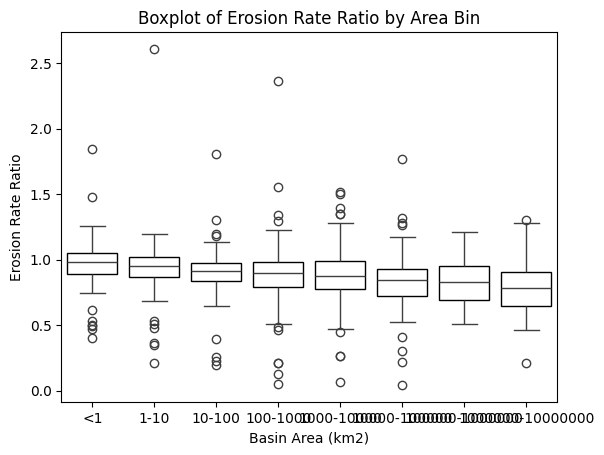

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot boxplots
sns.boxplot(x='Area_Category', y='Erosion_Rate_Ratio', data=df, boxprops=dict(facecolor='none', edgecolor='black'))
plt.title('Boxplot of Erosion Rate Ratio by Area Bin')
plt.xlabel('Basin Area (km2)')
plt.ylabel('Erosion Rate Ratio')
plt.show()

Testing for homogeneity of variances across basin area categories

In [41]:
from scipy.stats import levene

# Levene's test for homogeneity of variances - Basin Area
groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('Area_Category', observed=False)]
stat, p_value = levene(*groups)

# Display the results
print(f"Levene Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The variances are not homogeneous across groups.")
else:
    print("The variances appear to be homogeneous across groups.")

Levene Test Statistic: 0.8682747362354973
P-value: 0.5311801617154095
The variances appear to be homogeneous across groups.


Having passed the homogeneity of variances check, we move forward with a standard one-way ANOVA 

In [42]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

# Fit the model
model = ols('Erosion_Rate_Ratio ~ C(Area_Category)', data=df).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model, typ=2)

print(anova_results)

                     sum_sq     df         F    PR(>F)
C(Area_Category)   1.493490    7.0  4.593017  0.000048
Residual          35.210755  758.0       NaN       NaN


ANOVA indicates statistically-significant differences between the categories. Below we conduct multi-comparison of means and medians analyses to investigate the differences in more detail.

In [43]:
import pandas as pd

#Calculating the means, medians, and standard deviation of each group.
grouped_stats = df.groupby('Area_Category', observed=False)['Erosion_Rate_Ratio'].agg(['mean', 'median','std', 'count'])
print(grouped_stats)

                      mean    median       std  count
Area_Category                                        
<1                0.964693  0.981997  0.201785     83
1-10              0.933339  0.952699  0.277108     68
10-100            0.900493  0.910853  0.183493    119
100-1000          0.879735  0.899441  0.222614    180
1000-10000        0.867625  0.872987  0.212248    136
10000-100000      0.830683  0.846290  0.222211     91
100000-1000000    0.822219  0.826531  0.172156     64
1000000-10000000  0.790552  0.783903  0.249206     25


In [32]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Multi-comparison of means analysis with Tukey's HSD
posthoc = pairwise_tukeyhsd(df['Erosion_Rate_Ratio'], df['Area_Category'], alpha=0.05)
print(posthoc)

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
     group1           group2      meandiff p-adj   lower  upper  reject
-----------------------------------------------------------------------
            1-10           10-100  -0.0328 0.9741 -0.1324 0.0667  False
            1-10         100-1000  -0.0536  0.656 -0.1468 0.0396  False
            1-10       1000-10000  -0.0657 0.4469  -0.163 0.0316  False
            1-10     10000-100000  -0.1027 0.0607 -0.2077 0.0024  False
            1-10   100000-1000000  -0.1111 0.0626 -0.2252  0.003  False
            1-10 1000000-10000000  -0.1428 0.0886  -0.296 0.0104  False
            1-10               <1   0.0314  0.987 -0.0758 0.1385  False
          10-100         100-1000  -0.0208 0.9923 -0.0982 0.0566  False
          10-100       1000-10000  -0.0329 0.9275 -0.1151 0.0494  False
          10-100     10000-100000  -0.0698 0.2807  -0.161 0.0214  False
          10-100   100000-1000000  -0.0783 0.2717 -0.1798 0.0233

In [33]:
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Multi-comparison of medians analysis using Kruskal-Wallis H analysis
area_groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('Area_Category', observed=False)]

# Perform Kruskal-Wallis H test
h_statistic, p_value = stats.kruskal(*area_groups)

# Display the results
print(f"Kruskal-Wallis H Statistic: {h_statistic}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The medians of groups are significantly different.")
    # Perform post-hoc pairwise comparisons
    posthoc_results = sp.posthoc_dunn(df, val_col='Erosion_Rate_Ratio', group_col='Area_Category', p_adjust='bonferroni')
    print(posthoc_results)
else:
    print("The medians of groups are not significantly different.")

Kruskal-Wallis H Statistic: 57.080400767256556
P-value: 5.7616692754118e-10
The medians of groups are significantly different.
                            <1      1-10    10-100  100-1000  1000-10000  \
<1                1.000000e+00  1.000000  0.199574  0.002582    0.000385   
1-10              1.000000e+00  1.000000  1.000000  0.375120    0.087683   
10-100            1.995740e-01  1.000000  1.000000  1.000000    1.000000   
100-1000          2.582453e-03  0.375120  1.000000  1.000000    1.000000   
1000-10000        3.850844e-04  0.087683  1.000000  1.000000    1.000000   
10000-100000      8.446625e-07  0.000729  0.029543  0.343412    1.000000   
100000-1000000    7.167404e-06  0.002058  0.064537  0.561064    1.000000   
1000000-10000000  1.896303e-04  0.006609  0.098636  0.484648    1.000000   

                  10000-100000  100000-1000000  1000000-10000000  
<1                8.446625e-07        0.000007          0.000190  
1-10              7.288723e-04        0.002058        

C:\Users\halst\AppData\Local\Programs\Python\Python313\Lib\site-packages\scikit_posthocs\_posthocs.py:371: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_lens = x.groupby(_group_col)[_val_col].count()
C:\Users\halst\AppData\Local\Programs\Python\Python313\Lib\site-packages\scikit_posthocs\_posthocs.py:374: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x_ranks_avg = x.groupby(_group_col)["ranks"].mean()


Finally, calculating how many samples in each basin area category had erosion rate ratios below 1 (considering 2-sigma uncertainties). These results are shown in Table 2 in the main manuscript.

In [44]:
import pandas as pd

# Calculate the lower bound of the E_ratio considering uncertainty
df['E_ratio_upper_bound'] = df['Erosion_Rate_Ratio'] + 2*df['E_Ratio_Unc']

# Filter the DataFrame to include only rows where the lower bound is below 1
filtered_df = df[df['E_ratio_upper_bound'] < 1]

# Count the number of samples within each area category that meet the criteria
counts = filtered_df['Area_Category'].value_counts()

# Display the results
counts

# Calculate the total number of samples within each area category
total_counts = df['Area_Category'].value_counts()

# Calculate the percentage of samples with E_ratio below 1
percentage_counts = (counts / total_counts) * 100

# Combine counts and percentage_counts into a single DataFrame
results = pd.DataFrame({
    'Count': counts,
    'Percentage': percentage_counts
}).sort_index()

# Display the results sorted by the area categories from smallest to largest
results_sorted = results.sort_index()

# Display the results sorted by the area categories from smallest to largest
results_sorted = results.sort_index()

# Display the results using IPython display
from IPython.display import display
display(results_sorted)

,Count,Percentage
Area_Category,,
<1,11,13.253012
1-10,10,14.705882
10-100,30,25.210084
100-1000,58,32.222222
1000-10000,57,41.911765
10000-100000,38,41.758242
100000-1000000,25,39.062500
1000000-10000000,9,36.000000


In [ ]:
Hypsometric Integral ANOVA. First defining categories based on basin areas and then a visualization of these categories

In [33]:
import pandas as pd

# Define the bins and corresponding labels
bins = [-float('inf'), 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 1]
labels = ['0.1', '0.2', '0.3', '0.4', '0.5', '0.6', '0.7', '>0.7']
# Create a new column 'category' with the categorized values
df['HypsoCat'] = pd.cut(df['Hypso_Int'], bins=bins, labels=labels, right=False)


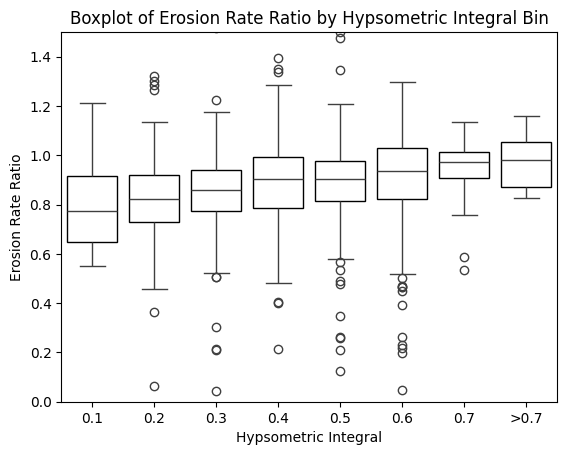

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot boxplots
sns.boxplot(x='HypsoCat', y='Erosion_Rate_Ratio', data=df, boxprops=dict(facecolor='none', edgecolor='black'))
plt.title('Boxplot of Erosion Rate Ratio by Hypsometric Integral Bin')
plt.xlabel('Hypsometric Integral')
plt.ylabel('Erosion Rate Ratio')
plt.ylim(0,1.5)

plt.savefig('HypsoANOVA.svg', format = 'svg')

plt.show()

Testing for homogeneity of variances across basin area categories

In [35]:
from scipy.stats import levene

# Levene's test for homogeneity of variances - Basin Area
groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('HypsoCat', observed=False)]
stat, p_value = levene(*groups)

# Display the results
print(f"Levene Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The variances are not homogeneous across groups.")
else:
    print("The variances appear to be homogeneous across groups.")

Levene Test Statistic: 0.9737947978905529
P-value: 0.449095282345766
The variances appear to be homogeneous across groups.


Having passed the homogeneity of variances check, we move forward with a standard one-way ANOVA 

In [40]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import seaborn as sns
import matplotlib.pyplot as plt

df_filtered = df.dropna(subset=['Hypso_Int'])

# Fit the model
model = ols('Erosion_Rate_Ratio ~ C(HypsoCat)', data=df_filtered).fit()

# Perform ANOVA
anova_results = sm.stats.anova_lm(model, typ=2)

print(anova_results)

                sum_sq     df         F    PR(>F)
C(HypsoCat)   0.933056    7.0  2.822333  0.006585
Residual     35.751760  757.0       NaN       NaN


ANOVA indicates statistically-significant differences between the categories. Below we conduct multi-comparison of means and medians analyses to investigate the differences in more detail.

In [41]:
import pandas as pd

#Calculating the means, medians, and standard deviation of each group.
grouped_stats = df.groupby('HypsoCat', observed=False)['Erosion_Rate_Ratio'].agg(['mean', 'median','std', 'count'])
print(grouped_stats)

              mean    median       std  count
HypsoCat                                     
0.1       0.810445  0.772574  0.205627     22
0.2       0.830399  0.821421  0.235353     60
0.3       0.839617  0.859375  0.196570    115
0.4       0.892539  0.905146  0.226699    164
0.5       0.894486  0.904545  0.220148    215
0.6       0.888595  0.934694  0.220436    147
0.7       0.946412  0.973510  0.131688     31
>0.7      1.037972  0.982262  0.287690     11


In [42]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

#One NaN entry has to be removed
filtered_df = df.dropna(subset=['HypsoCat'])

# Multi-comparison of means analysis with Tukey's HSD
posthoc = pairwise_tukeyhsd(filtered_df['Erosion_Rate_Ratio'], filtered_df['HypsoCat'], alpha=0.05)
print(posthoc)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
   0.1    0.2     0.02    1.0 -0.1447 0.1846  False
   0.1    0.3   0.0292 0.9991 -0.1245 0.1829  False
   0.1    0.4   0.0821 0.7108 -0.0679 0.2321  False
   0.1    0.5    0.084 0.6691 -0.0638 0.2319  False
   0.1    0.6   0.0781 0.7664 -0.0728 0.2291  False
   0.1    0.7    0.136 0.3264 -0.0482 0.3201  False
   0.1   >0.7   0.2275  0.088 -0.0164 0.4714  False
   0.2    0.3   0.0092    1.0  -0.096 0.1144  False
   0.2    0.4   0.0621 0.5547 -0.0375 0.1618  False
   0.2    0.5   0.0641 0.4691 -0.0324 0.1605  False
   0.2    0.6   0.0582 0.6555  -0.043 0.1594  False
   0.2    0.7    0.116 0.2362 -0.0301 0.2621  False
   0.2   >0.7   0.2076 0.0716 -0.0091 0.4242  False
   0.3    0.4   0.0529  0.481 -0.0274 0.1333  False
   0.3    0.5   0.0549 0.3617 -0.0214 0.1312  False
   0.3    0.6    0.049 0.6132 -0.0333 0.1312  False
   0.3    0.

In [43]:
import pandas as pd

# Calculate the lower bound of the E_ratio considering uncertainty
df['E_ratio_upper_bound'] = df['Erosion_Rate_Ratio'] + 2*df['E_Ratio_Unc']

# Filter the DataFrame to include only rows where the lower bound is below 1
filtered_df = df[df['E_ratio_upper_bound'] < 1]

# Count the number of samples within each area category that meet the criteria
counts = filtered_df['HypsoCat'].value_counts()

# Display the results
counts

# Calculate the total number of samples within each area category
total_counts = df['HypsoCat'].value_counts()

# Calculate the percentage of samples with E_ratio below 1
percentage_counts = (counts / total_counts) * 100

# Combine counts and percentage_counts into a single DataFrame
results = pd.DataFrame({
    'Count': counts,
    'Percentage': percentage_counts
}).sort_index()

# Display the results sorted by the area categories from smallest to largest
results_sorted = results.sort_index()

# Display the results sorted by the area categories from smallest to largest
results_sorted = results.sort_index()

# Display the results using IPython display
from IPython.display import display
display(results_sorted)

,Count,Percentage
HypsoCat,,
0.1,8,36.363636
0.2,29,48.333333
0.3,50,43.478261
0.4,55,33.536585
0.5,55,25.581395
0.6,32,21.768707
0.7,7,22.580645
>0.7,1,9.090909


ANOVA test for lithology

In [45]:
#Displaying the number of basins in each dominant lithology category
print(f"Unique values in {'Lithology'}:")
print(df['Lithology'].value_counts())

Unique values in Lithology:
Lithology
Siliciclastic Sedimentary Rocks    226
Acid Plutonic Rocks                134
Mixed Sedimentary Rocks            107
Unconsolidated Sediments           105
Metamorphic Rocks                  104
Acid Volcanic Rocks                 29
Carbonate Sedimentary Rocks         28
Basic Volcanic Rocks                14
Intermediate Volcanic Rocks          9
Pyroclastic                          6
Basic Plutonic Rocks                 2
Intermediate Plutonic Rocks          2
Name: count, dtype: int64


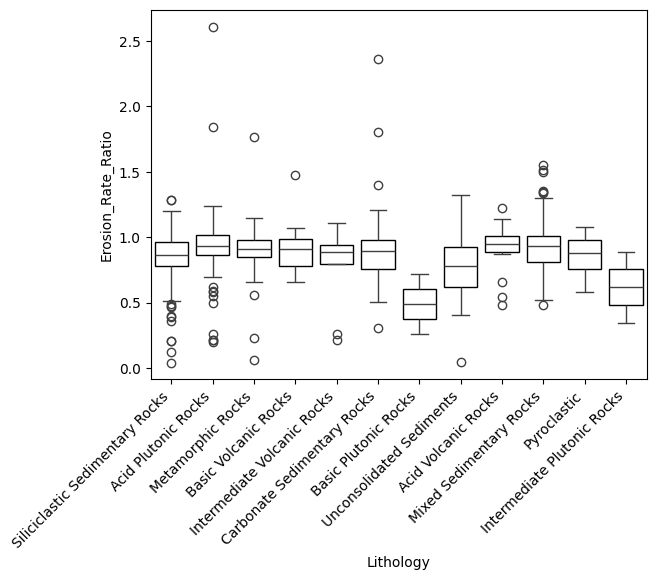

In [46]:
import seaborn as sns

sns.boxplot(x='Lithology', y='Erosion_Rate_Ratio', data=df, boxprops=dict(facecolor='none', edgecolor='black'))
plt.xticks(rotation=45, ha='right')
plt.show()

In [47]:
from scipy.stats import levene

# Levene's test for homogeneity of variances - Lithology
groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('Lithology')]
stat, p_value = levene(*groups)

# Display the results
print(f"Levene Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The variances are not homogeneous across groups.")
else:
    print("The variances appear to be homogeneous across groups.")

Levene Test Statistic: 2.7381340032136823
P-value: 0.0017601674792883744
The variances are not homogeneous across groups.


Based on the boxplots of lithologies, it looks like the single Basic Plutonic basin may be throwing this off. We'll proceed without that basin

In [48]:
df_filtered = df[df['Lithology'] != 'Basic Plutonic Rocks']

groups = [group[1]['Erosion_Rate_Ratio'] for group in df_filtered.groupby('Lithology')]
stat, p_value = levene(*groups)

# Display the results
print(f"Levene Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The variances are not homogeneous across groups.")
else:
    print("The variances appear to be homogeneous across groups.")

Levene Test Statistic: 2.9429868971721977
P-value: 0.001235875853030157
The variances are not homogeneous across groups.


There is still heterogeneity across groups, so we will jump straight into means and medians comparison

In [49]:
import pandas as pd

# Assuming 'df' is your DataFrame
#Removing Basic Plutonic Rocks because there is only 1 basin in that category and it has a very low ratio
df_filtered = df[df['Lithology'] != 'Basic Plutonic Rocks']
grouped_stats = df_filtered.groupby('Lithology')['Erosion_Rate_Ratio'].agg(['mean', 'std','median', 'count'])
print(grouped_stats)

                                     mean       std    median  count
Lithology                                                           
Acid Plutonic Rocks              0.934840  0.241727  0.930646    134
Acid Volcanic Rocks              0.935495  0.157720  0.948052     29
Basic Volcanic Rocks             0.923249  0.200944  0.907086     14
Carbonate Sedimentary Rocks      0.938019  0.393871  0.893329     28
Intermediate Plutonic Rocks      0.619223  0.381827  0.619223      2
Intermediate Volcanic Rocks      0.772857  0.321619  0.888446      9
Metamorphic Rocks                0.902391  0.170356  0.912963    104
Mixed Sedimentary Rocks          0.927565  0.207359  0.932065    107
Pyroclastic                      0.859096  0.180459  0.882190      6
Siliciclastic Sedimentary Rocks  0.855625  0.177766  0.862671    226
Unconsolidated Sediments         0.787034  0.222070  0.783903    105


In [50]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Post-hoc analysis with Tukey's HSD
posthoc = pairwise_tukeyhsd(df_filtered['Erosion_Rate_Ratio'], df_filtered['Lithology'], alpha=0.05)
print(posthoc)

                         Multiple Comparison of Means - Tukey HSD, FWER=0.05                          
             group1                          group2             meandiff p-adj   lower   upper  reject
------------------------------------------------------------------------------------------------------
            Acid Plutonic Rocks             Acid Volcanic Rocks   0.0007    1.0 -0.1401  0.1414  False
            Acid Plutonic Rocks            Basic Volcanic Rocks  -0.0116    1.0 -0.2046  0.1814  False
            Acid Plutonic Rocks     Carbonate Sedimentary Rocks   0.0032    1.0 -0.1396   0.146  False
            Acid Plutonic Rocks     Intermediate Plutonic Rocks  -0.3156 0.5907 -0.8051  0.1739  False
            Acid Plutonic Rocks     Intermediate Volcanic Rocks   -0.162  0.498 -0.3986  0.0746  False
            Acid Plutonic Rocks               Metamorphic Rocks  -0.0324 0.9858 -0.1222  0.0573  False
            Acid Plutonic Rocks         Mixed Sedimentary Rocks  -0.0073 

In [51]:
import pandas as pd
import scipy.stats as stats
import scikit_posthocs as sp
import seaborn as sns
import matplotlib.pyplot as plt

# Multi-comparison of medians analysis using Kruskal-Wallis H analysis
area_groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('Lithology', observed=False)]

# Perform Kruskal-Wallis H test
h_statistic, p_value = stats.kruskal(*area_groups)

# Display the results
print(f"Kruskal-Wallis H Statistic: {h_statistic}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The medians of groups are significantly different.")
    # Perform post-hoc pairwise comparisons
    posthoc_results = sp.posthoc_dunn(df, val_col='Erosion_Rate_Ratio', group_col='Lithology', p_adjust='bonferroni')
    print(posthoc_results)
else:
    print("The medians of groups are not significantly different.")

Kruskal-Wallis H Statistic: 59.712762343061364
P-value: 1.0483697144211122e-08
The medians of groups are significantly different.
                                 Acid Plutonic Rocks  Acid Volcanic Rocks  \
Acid Plutonic Rocks                     1.000000e+00             1.000000   
Acid Volcanic Rocks                     1.000000e+00             1.000000   
Basic Plutonic Rocks                    9.344620e-01             0.789386   
Basic Volcanic Rocks                    1.000000e+00             1.000000   
Carbonate Sedimentary Rocks             1.000000e+00             1.000000   
Intermediate Plutonic Rocks             1.000000e+00             1.000000   
Intermediate Volcanic Rocks             1.000000e+00             1.000000   
Metamorphic Rocks                       1.000000e+00             1.000000   
Mixed Sedimentary Rocks                 1.000000e+00             1.000000   
Pyroclastic                             1.000000e+00             1.000000   
Siliciclastic Sedimenta

Tectonic Activity ANOVA:

In [52]:
import pandas as pd

grouped_stats = df.groupby('STR_Class')['Erosion_Rate_Ratio'].agg(['mean','median', 'std', 'count'])
print(grouped_stats)

                   mean    median       std  count
STR_Class                                         
Active         0.927276  0.941748  0.222524    411
Post-Orogenic  0.827921  0.850980  0.202540    355


In [53]:
groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('STR_Class')]
stat, p_value = levene(*groups)

# Display the results
print(f"Levene Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The variances are not homogeneous across groups.")
else:
    print("The variances appear to be homogeneous across groups.")

Levene Test Statistic: 1.317076055179557
P-value: 0.2514767191456924
The variances appear to be homogeneous across groups.


t-Test Statistic: 6.4226616013281905
P-value: 2.352730762844774e-10
The means of groups are significantly different.


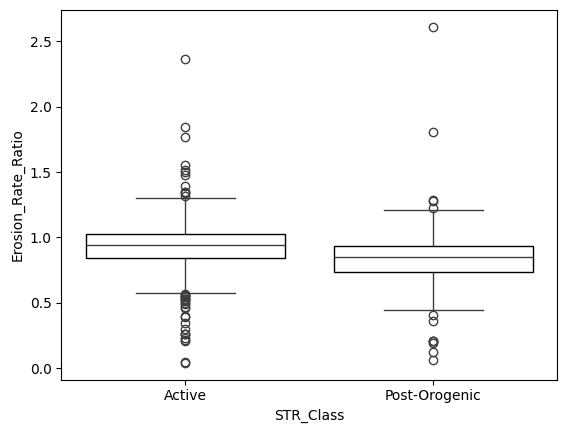

In [54]:
import scipy.stats as stats

tec_groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('STR_Class')]

t_statistic, p_value = stats.ttest_ind(*tec_groups)

# Display the results
print(f"t-Test Statistic: {t_statistic}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The means of groups are significantly different.")
else:
    print("The means of groups are not significantly different.")
    
sns.boxplot(x='STR_Class', y='Erosion_Rate_Ratio', data=df, boxprops=dict(facecolor='none', edgecolor='black'))
plt.savefig('Tectonics_ANOVA.svg', format='svg', bbox_inches='tight')

In [55]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Post-hoc analysis with Tukey's HSD
posthoc = pairwise_tukeyhsd(df['Erosion_Rate_Ratio'], df['STR_Class'], alpha=0.05)
print(posthoc)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
group1     group2    meandiff p-adj  lower  upper  reject
---------------------------------------------------------
Active Post-Orogenic  -0.0994   0.0 -0.1297 -0.069   True
---------------------------------------------------------


Mann-Whitney U Statistic: 99683.5
P-value: 2.0744779524651366e-18
The medians of groups are significantly different.


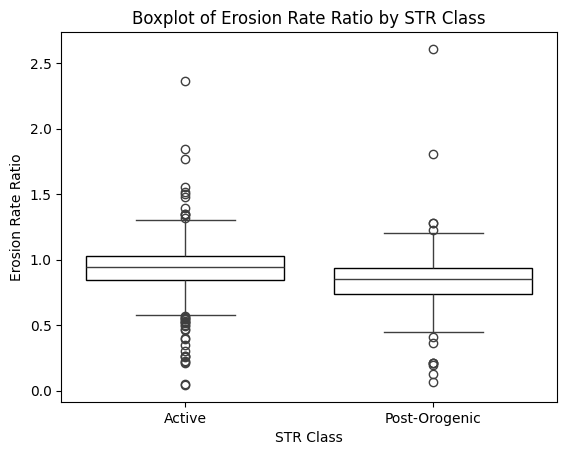

In [56]:
#The same but with medians instead of means
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Grouping the data by 'STR_Class' and getting the 'Erosion_Rate_Ratio' values
tec_groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('STR_Class')]

# Perform Mann-Whitney U test
u_statistic, p_value = stats.mannwhitneyu(*tec_groups, alternative='two-sided')

# Display the results
print(f"Mann-Whitney U Statistic: {u_statistic}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The medians of groups are significantly different.")
else:
    print("The medians of groups are not significantly different.")

# Plot boxplots
sns.boxplot(x='STR_Class', y='Erosion_Rate_Ratio', data=df, boxprops=dict(facecolor='none', edgecolor='black'))
plt.title('Boxplot of Erosion Rate Ratio by STR Class')
plt.xlabel('STR Class')
plt.ylabel('Erosion Rate Ratio')
plt.show()

Categorizing based on LGM ice cover

In [45]:
import pandas as pd

# Create a new column 'Has_Value' that is True if basins have more than 10% LGM ice cover, and False if they do not
df['Has_LGMice'] = df['LGM_ice'] > 10

In [46]:
import pandas as pd

grouped_stats = df.groupby('Has_LGMice')['Erosion_Rate_Ratio'].agg(['mean','median', 'std', 'count'])
print(grouped_stats)

                mean    median       std  count
Has_LGMice                                     
False       0.877082  0.889590  0.213189    649
True        0.904243  0.940476  0.248788    117


In [47]:
from scipy.stats import levene

groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('Has_LGMice')]
stat, p_value = levene(*groups)

# Display the results
print(f"Levene Test Statistic: {stat}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The variances are not homogeneous across groups.")
else:
    print("The variances appear to be homogeneous across groups.")

Levene Test Statistic: 5.011396721670234
P-value: 0.02546820139528811
The variances are not homogeneous across groups.


t-Test Statistic: -1.2349932047138428
P-value: 0.217212698625395
The means of groups are not significantly different.


<Axes: xlabel='Has_LGMice', ylabel='Erosion_Rate_Ratio'>

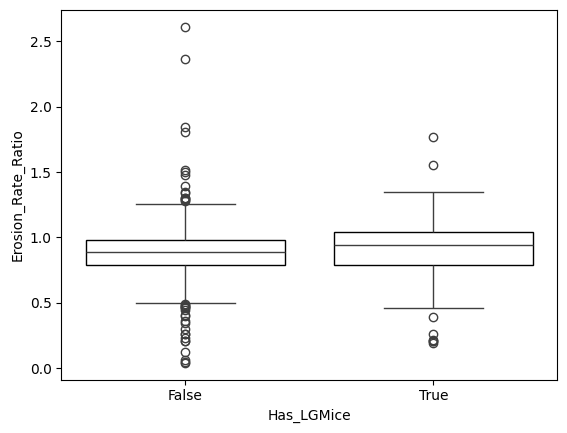

In [48]:
import scipy.stats as stats

LGM_groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('Has_LGMice')]

t_statistic, p_value = stats.ttest_ind(*LGM_groups)

# Display the results
print(f"t-Test Statistic: {t_statistic}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The means of groups are significantly different.")
else:
    print("The means of groups are not significantly different.")
    
sns.boxplot(x='Has_LGMice', y='Erosion_Rate_Ratio', data=df, boxprops=dict(facecolor='none', edgecolor='black'))
#plt.savefig('LGMice_ANOVA.svg', format='svg', bbox_inches='tight')

In [79]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Post-hoc analysis with Tukey's HSD
posthoc = pairwise_tukeyhsd(df['Erosion_Rate_Ratio'], df['Has_LGMice'], alpha=0.05)
print(posthoc)

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower  upper  reject
--------------------------------------------------
 False   True   0.0272 0.2172 -0.016 0.0703  False
--------------------------------------------------


There does not seem to be a statistically-significant different in erosion rate ratios between basins with more than 10% LGM ice cover and those without.

Mann-Whitney U Statistic: 32653.0
P-value: 0.01587968003653735
The medians of groups are significantly different.


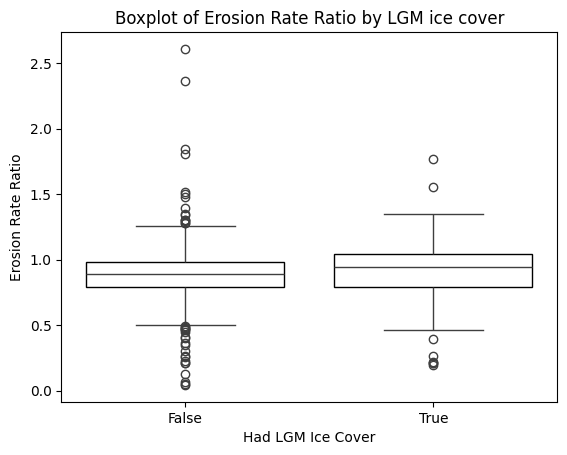

In [50]:
#The same but with medians instead of means
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your existing DataFrame
# Grouping the data by 'STR_Class' and getting the 'Erosion_Rate_Ratio' values
LGM_groups = [group[1]['Erosion_Rate_Ratio'] for group in df.groupby('Has_LGMice')]

# Perform Mann-Whitney U test
u_statistic, p_value = stats.mannwhitneyu(*LGM_groups, alternative='two-sided')

# Display the results
print(f"Mann-Whitney U Statistic: {u_statistic}")
print(f"P-value: {p_value}")

# Check the p-value against a significance level (e.g., 0.05)
if p_value < 0.05:
    print("The medians of groups are significantly different.")
else:
    print("The medians of groups are not significantly different.")

# Plot boxplots
sns.boxplot(x='Has_LGMice', y='Erosion_Rate_Ratio', data=df, boxprops=dict(facecolor='none', edgecolor='black'))
plt.title('Boxplot of Erosion Rate Ratio by LGM ice cover')
plt.xlabel('Had LGM Ice Cover')
plt.ylabel('Erosion Rate Ratio')
plt.show()

Here is the code to produce Figure 2, the plot of sample basins based on latitude and elevation, with marker color based on denudation rate ratios and marker size based on basin areas. Note: you will have to have run the previous code blocks defining the variables 'Category 2S' and 'Area_Category' for this to work.

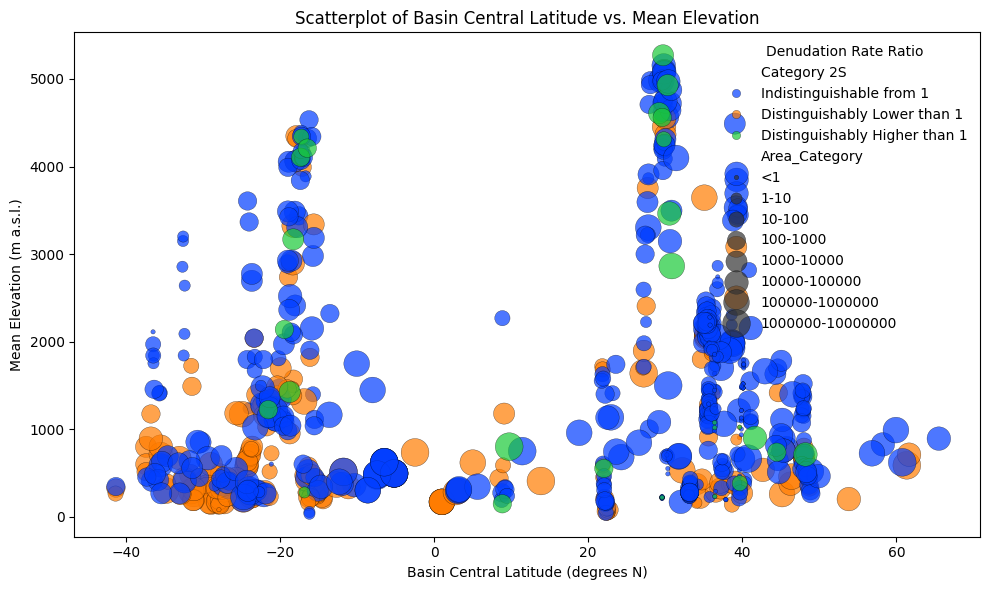

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Define a function to categorize each sample based on the individual error
def categorize_based_on_uncertainty(row):
    erosion_rate = row['Erosion_Rate_Ratio']
    unc = 2*row['E_Ratio_Unc']
    
    # Define the thresholds based on the error (uncertainty)
    lower_threshold = erosion_rate - unc
    upper_threshold = erosion_rate + unc
    
    # Categorize the sample
    if lower_threshold <= 1 <= upper_threshold:
        return 'Indistinguishable from 1'
    elif erosion_rate < 1 - unc:
        return 'Distinguishably Lower than 1'
    elif erosion_rate > 1 + unc:
        return 'Distinguishably Higher than 1'
    else:
        return 'Indistinguishable from 1'

# Apply the categorization function to each row and create a new 'Category' column
df['Category 2S'] = df.apply(categorize_based_on_uncertainty, axis=1)

bins = [-float('inf'), 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]
labels = ['<1', '1-10', '10-100', '100-1000', '1000-10000', '10000-100000', '100000-1000000', '1000000-10000000']
# Create a new column 'category' with the categorized values
df['Area_Category'] = pd.cut(df['Basin_Area'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df,
                x='Basin_Central_Latitude',
                y='Mean_Elevation',
                hue='Category 2S',  # Color code based on 'Category 2S'
                size='Area_Category',  # Size of markers based on 'Area_Category'
                sizes=(400, 10),  # You can adjust the range of marker sizes
                palette='bright',  # Choose a color palette for 'Category 2S'
                legend='full',  # Show the legend
                edgecolor='black',  # Optional: Adds edge color to the markers
                alpha=0.7)  # Optional: Sets transparency of the markers

# Set the title and labels for the axes
plt.title('Scatterplot of Basin Central Latitude vs. Mean Elevation')
plt.xlabel('Basin Central Latitude (degrees N)')
plt.ylabel('Mean Elevation (m a.s.l.)')

# Customize the legend
# Change the title of the legend
plt.legend(title='Denudation Rate Ratio', loc='upper right', frameon=False, fontsize=10)

plt.savefig('Figure2.svg', format='svg', bbox_inches='tight')

# Display the plot
plt.tight_layout()
plt.show()